# Mini Project 7 :- Customer Churn Prediction Using Supervised Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["Churn"].value_counts()   # churn mtlb kitne customers leave kr rhe h ya company chordke ja rhe h

Churn
No     5174
Yes    1869
Name: count, dtype: int64

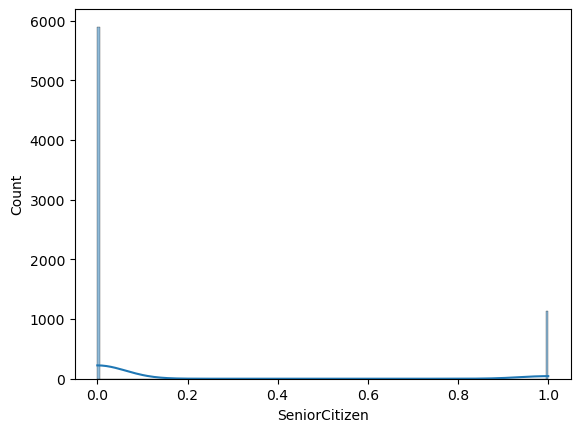

In [11]:
sns.histplot(df["SeniorCitizen"], kde=True)
plt.show()

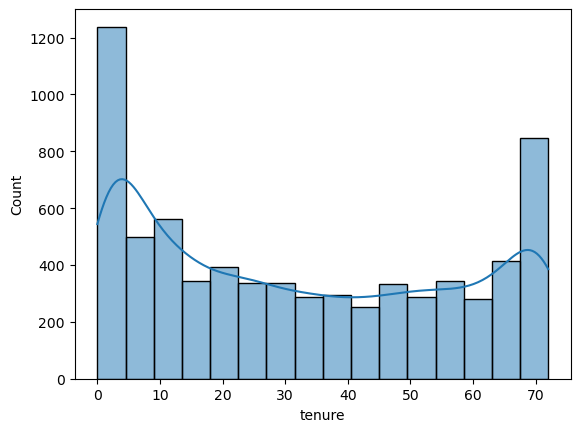

In [12]:
sns.histplot(df["tenure"], kde=True)
plt.show()

In [13]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [14]:
# TotalCharges ko numeric me convert karna
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
# errors="coerce" :- Invalid values aur blank spaces ko NaN me convert karne ke liye.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
# Median se fill kyu?? qki median outliers se kam affect hota hai aur numerical missing values ke liye suitable hota hai.

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

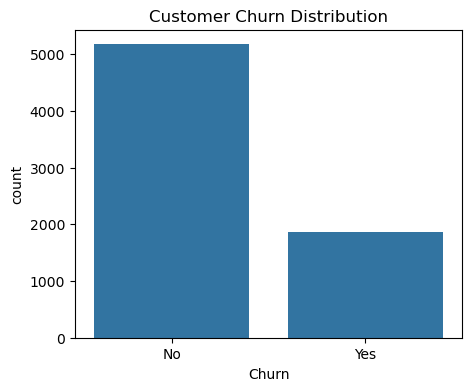

In [19]:
# Churn aur Non-Churn customers ka count dekhna---
# Is graph se pata chalega kitne customers company chord chuke hain
# aur kitne customers abhi bhi company ke saath hain
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

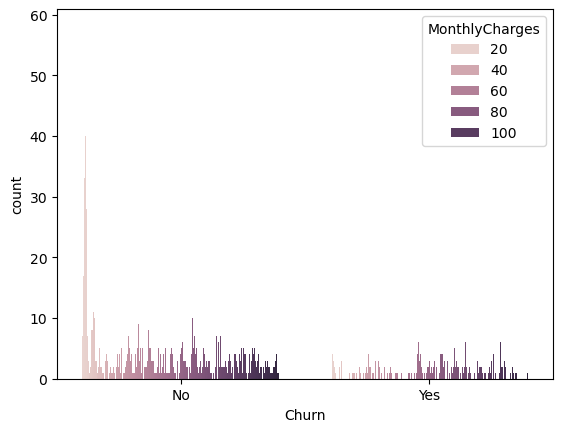

In [20]:
# Monthly charges aur churn ke beech relationship dekhna
sns.countplot(x="Churn",hue="MonthlyCharges",data=df)
plt.show()
# High charges wale customers churn kar rahe hain ya nahi

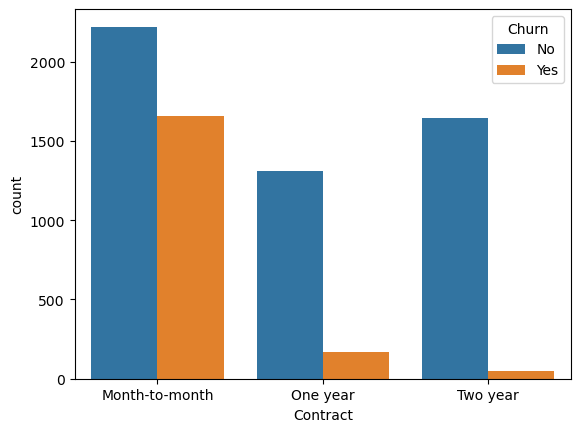

In [21]:
# Contract type ka churn par effect dekhna
sns.countplot(x="Contract",hue="Churn",data=df)
plt.show()
# Kis contract type me sabse zyada churn ho raha hai

In [22]:
# Encoding :- before heatmap
# Text data ko numbers me convert karna
# Machine Learning algorithms text ko directly nahi samajhte

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [24]:
# sabhi Object datatype wale columns identify karna
cat_cols = df.select_dtypes(include="object").columns

In [25]:
# Encoding
# Sabhi categorical columns ko numerical values me convert karna
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   int64  
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


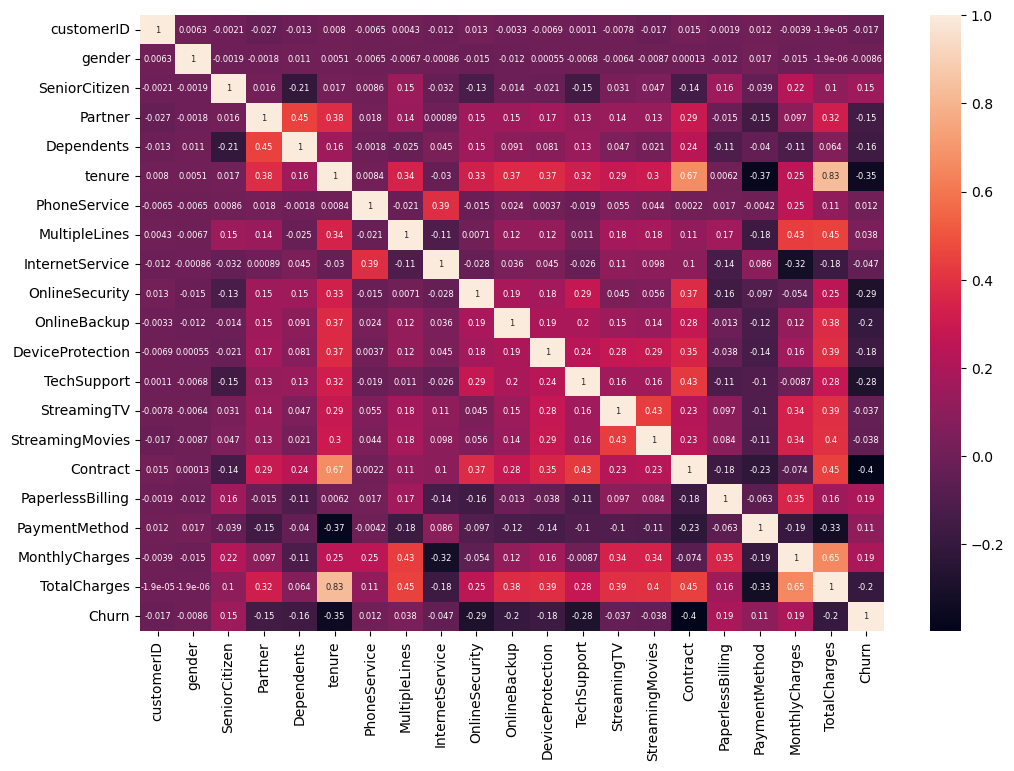

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,annot_kws={"size":6})
plt.show()

# Positive correlation = dono saath increase/decrease hote hain
# Negative correlation = ek increase to dusra decrease

In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [29]:
# Feature Selection :-

# Input Features
X = df.drop("Churn", axis=1)

# Target Variable
Y = df["Churn"]

# Train-Test-Split

In [30]:
from sklearn.model_selection import train_test_split

# Data ko training aur testing me divide karna

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [32]:
# Linear Regression kyu nahi use kiya?
# Kyuki hamara target variable "Churn" categorical hai, numerical nahi.,isme yes , no and encoding ke baad 0, 1 hai prr ye categories hai

# Supervised Machine Learning Algorithms :-

# Logistic Regression 

In [33]:
# Logistic Regression model create karna
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

# Model ko training data par train karna
lr.fit(X_train, Y_train)

C:\Users\cxash\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
y_pred_lr = lr.predict(X_test)    # Test data par prediction karna

In [35]:
y_pred_lr

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

# Decision Tree Classifier 

In [36]:
# Decision Tree model create karna
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
# Model train karna
dt.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
y_pred_dt = dt.predict(X_test)      # Decision Tree se prediction karna

# Accuracy :-

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
print("LR :", accuracy_score(Y_test, y_pred_lr))
print("DT :", accuracy_score(Y_test, y_pred_dt))

LR : 0.8161816891412349
DT : 0.7281760113555713


# Classification Report 

In [40]:
from sklearn.metrics import classification_report
# Precision, Recall aur F1 Score dekhna
print(classification_report(Y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.67      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



# Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test,y_pred_lr)
cm
# Model ne kitni predictions sahi aur galat ki dekhna

array([[929, 107],
       [152, 221]])

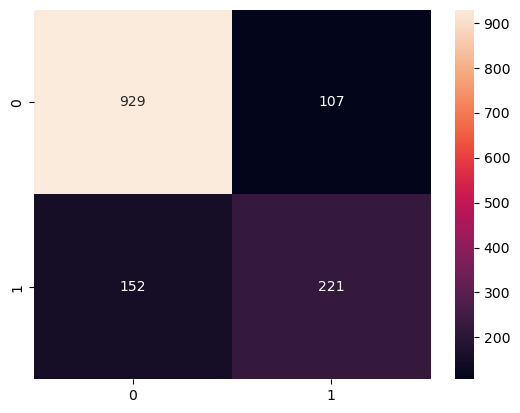

In [42]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

# Conclusion :-

In [43]:
#Logistic Regression achieved the highest accuracy among all models and was selected as the best model for customer churn prediction.

# Logistic Regression aur Decision Tree models train kiye gaye
# Dono models ki accuracy compare ki gayi
# Jis model ki accuracy highest rahi usse best model select kiya gaya
# Is model ka use future customers ke churn prediction ke liye kiya ja sakta hai